##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [6]:
!pip install -q keras-cv tensorflow-datasets

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
import keras_cv

print("TensorFlow version:", tf.__version__)
print("KerasCV version:", keras_cv.__version__)

TensorFlow version: 2.19.0
KerasCV version: 0.9.0


In [8]:
# Try a few Pascal VOC presets in case one name is unavailable in your KerasCV version
preset_candidates = [
    "yolo_v8_m_pascalvoc",
    "yolo_v8_s_pascalvoc",
    "yolo_v8_xs_pascalvoc",
]

detector = None
loaded_preset = None

for preset in preset_candidates:
    try:
        detector = keras_cv.models.YOLOV8Detector.from_preset(
            preset,
            bounding_box_format="xywh"
        )
        loaded_preset = preset
        break
    except Exception as e:
        print(f"Preset {preset} not available: {e}")

if detector is None:
    raise ValueError("Could not load any Pascal VOC YOLOv8 preset.")

print("Loaded preset:", loaded_preset)

Loaded preset: yolo_v8_m_pascalvoc


In [9]:
builder = tfds.builder("voc/2012")
builder.download_and_prepare()

label_names = builder.info.features["objects"]["label"].names
num_classes = len(label_names)

print("Number of classes:", num_classes)
print("First 10 classes:", label_names[:10])

Number of classes: 20
First 10 classes: ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow']


In [10]:
ds = tfds.load("voc/2012", split="train", shuffle_files=False)
print(ds)

<_PrefetchDataset element_spec={'image': TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), 'image/filename': TensorSpec(shape=(), dtype=tf.string, name=None), 'labels': TensorSpec(shape=(None,), dtype=tf.int64, name=None), 'labels_no_difficult': TensorSpec(shape=(None,), dtype=tf.int64, name=None), 'objects': {'bbox': TensorSpec(shape=(None, 4), dtype=tf.float32, name=None), 'is_difficult': TensorSpec(shape=(None,), dtype=tf.bool, name=None), 'is_truncated': TensorSpec(shape=(None,), dtype=tf.bool, name=None), 'label': TensorSpec(shape=(None,), dtype=tf.int64, name=None), 'pose': TensorSpec(shape=(None,), dtype=tf.int64, name=None)}}>


In [11]:
TARGET_CLASSES = ["person", "dog", "car", "cat", "bicycle"]
TARGET_SIZE = (640, 640)

selected_images = []
selected_main_class = []
selected_true_boxes = []
selected_true_labels = []

for sample in tfds.as_numpy(ds):
    image = sample["image"]
    labels = sample["objects"]["label"]
    boxes = sample["objects"]["bbox"]   # ymin, xmin, ymax, xmax normalized

    class_names_in_image = [label_names[int(x)] for x in labels]

    chosen_target = None
    for t in TARGET_CLASSES:
        if t in class_names_in_image:
            chosen_target = t
            break

    if chosen_target is None:
        continue

    h, w = image.shape[:2]

    img_resized = tf.image.resize(image, TARGET_SIZE).numpy().astype("float32")

    gt_boxes_xywh = []
    gt_labels_names = []

    for b, lab in zip(boxes, labels):
        ymin, xmin, ymax, xmax = b
        x = float(xmin * TARGET_SIZE[1])
        y = float(ymin * TARGET_SIZE[0])
        bw = float((xmax - xmin) * TARGET_SIZE[1])
        bh = float((ymax - ymin) * TARGET_SIZE[0])

        gt_boxes_xywh.append([x, y, bw, bh])
        gt_labels_names.append(label_names[int(lab)])

    selected_images.append(img_resized)
    selected_main_class.append(chosen_target)
    selected_true_boxes.append(gt_boxes_xywh)
    selected_true_labels.append(gt_labels_names)

    if len(selected_images) == 5:
        break

assert len(selected_images) == 5, "Could not collect 5 images. Try changing TARGET_CLASSES."

images_np = np.stack(selected_images).astype("float32")

print("Selected target classes:", selected_main_class)
print("Images batch shape:", images_np.shape)
print("dtype:", images_np.dtype)

Selected target classes: ['dog', 'person', 'person', 'person', 'person']
Images batch shape: (5, 640, 640, 3)
dtype: float32


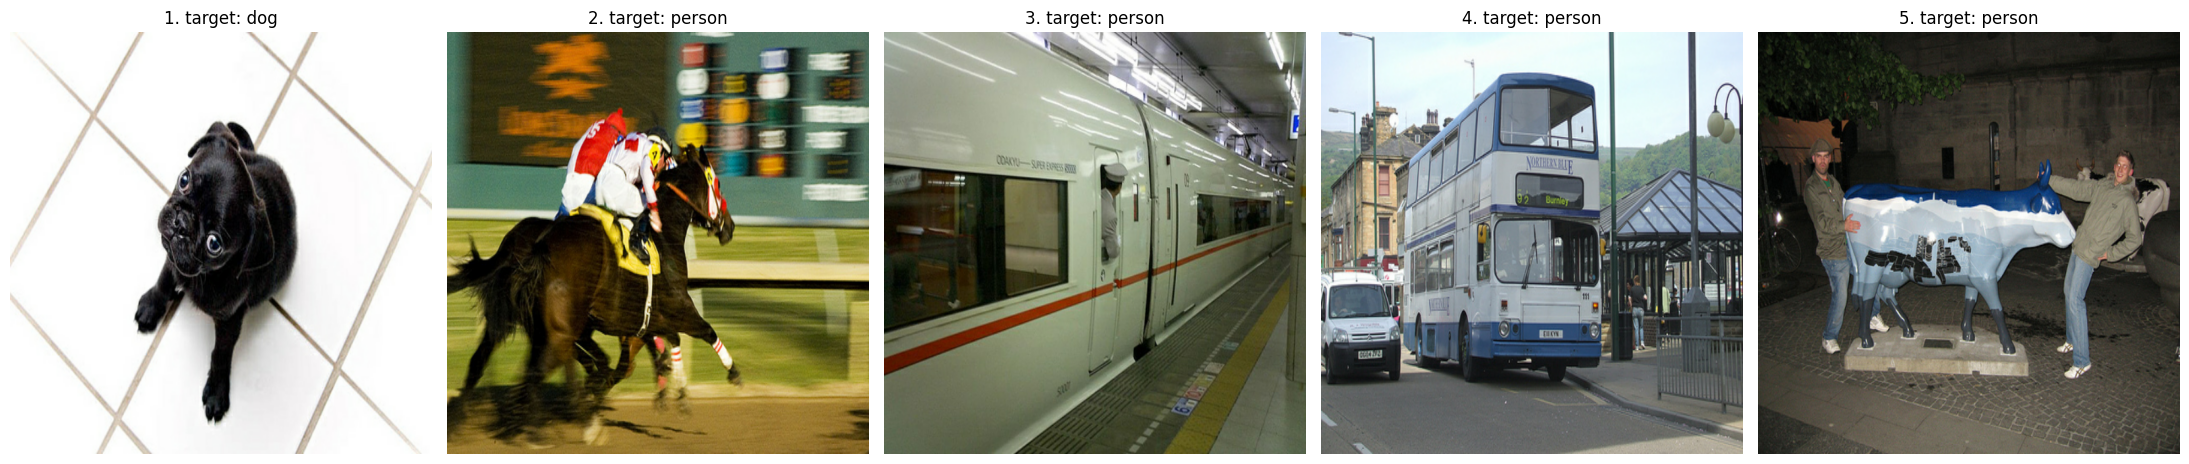

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, ax in enumerate(axes):
    ax.imshow(images_np[i].astype("uint8"))
    ax.set_title(f"{i+1}. target: {selected_main_class[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
predictions = detector.predict(images_np, verbose=0)

print(type(predictions))
if isinstance(predictions, dict):
    print("Prediction keys:", predictions.keys())

<class 'dict'>
Prediction keys: dict_keys(['boxes', 'confidence', 'classes', 'num_detections'])


In [14]:
def xywh_to_xyxy(box):
    x, y, w, h = box
    return [x, y, x + w, y + h]

def compute_iou(box1, box2):
    x1_min, y1_min, x1_max, y1_max = xywh_to_xyxy(box1)
    x2_min, y2_min, x2_max, y2_max = xywh_to_xyxy(box2)

    inter_xmin = max(x1_min, x2_min)
    inter_ymin = max(y1_min, y2_min)
    inter_xmax = min(x1_max, x2_max)
    inter_ymax = min(y1_max, y2_max)

    inter_w = max(0, inter_xmax - inter_xmin)
    inter_h = max(0, inter_ymax - inter_ymin)
    inter_area = inter_w * inter_h

    area1 = max(0, x1_max - x1_min) * max(0, y1_max - y1_min)
    area2 = max(0, x2_max - x2_min) * max(0, y2_max - y2_min)

    union = area1 + area2 - inter_area
    if union == 0:
        return 0.0

    return inter_area / union

In [15]:
all_pred_boxes = predictions["boxes"]
all_pred_classes = predictions["classes"]
all_pred_conf = predictions["confidence"]

print("Boxes shape:", np.array(all_pred_boxes).shape)
print("Classes shape:", np.array(all_pred_classes).shape)
print("Confidence shape:", np.array(all_pred_conf).shape)

Boxes shape: (5, 100, 4)
Classes shape: (5, 100)
Confidence shape: (5, 100)


In [16]:
IOU_THRESHOLD = 0.5
CONF_THRESHOLD = 0.25

results = []

for i in range(len(images_np)):
    pred_boxes = np.array(all_pred_boxes[i])
    pred_classes = np.array(all_pred_classes[i]).astype(int)
    pred_conf = np.array(all_pred_conf[i])

    valid_mask = pred_conf >= CONF_THRESHOLD
    pred_boxes = pred_boxes[valid_mask]
    pred_classes = pred_classes[valid_mask]
    pred_conf = pred_conf[valid_mask]

    pred_labels_names = [label_names[c] if 0 <= c < len(label_names) else str(c) for c in pred_classes]

    gt_boxes = selected_true_boxes[i]
    gt_labels = selected_true_labels[i]

    matched_gt = set()
    matched_pred = set()

    correct_detections = 0
    best_conf_scores = []

    for p_idx, (p_box, p_label, p_score) in enumerate(zip(pred_boxes, pred_labels_names, pred_conf)):
        best_iou = 0
        best_gt_idx = -1

        for g_idx, (g_box, g_label) in enumerate(zip(gt_boxes, gt_labels)):
            if g_idx in matched_gt:
                continue
            if p_label != g_label:
                continue

            iou = compute_iou(p_box, g_box)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = g_idx

        if best_iou >= IOU_THRESHOLD and best_gt_idx != -1:
            correct_detections += 1
            matched_gt.add(best_gt_idx)
            matched_pred.add(p_idx)
            best_conf_scores.append(float(p_score))

    missed_objects = [gt_labels[g] for g in range(len(gt_labels)) if g not in matched_gt]
    incorrect_labels = [pred_labels_names[p] for p in range(len(pred_labels_names)) if p not in matched_pred]

    results.append({
        "Image": i + 1,
        "Main Target Class": selected_main_class[i],
        "Correct Detections": correct_detections,
        "Confidence Scores": [round(x, 3) for x in best_conf_scores],
        "Missed Objects": missed_objects,
        "Incorrect Labels": incorrect_labels
    })

results_df = pd.DataFrame(results)
results_df

,Image,Main Target Class,Correct Detections,Confidence Scores,Missed Objects,Incorrect Labels
0,1,dog,1,[0.989],[],[]
1,2,person,1,[0.671],"[horse, person, person]",[]
2,3,person,1,[0.972],[person],[]
3,4,person,3,"[0.951, 0.908, 0.863]",[person],[]
4,5,person,2,"[0.964, 0.948]","[cow, cow, bicycle]","[train, train]"


In [18]:
pd.set_option("display.max_colwidth", None)
results_df

,Image,Main Target Class,Correct Detections,Confidence Scores,Missed Objects,Incorrect Labels
0,1,dog,1,[0.989],[],[]
1,2,person,1,[0.671],"[horse, person, person]",[]
2,3,person,1,[0.972],[person],[]
3,4,person,3,"[0.951, 0.908, 0.863]",[person],[]
4,5,person,2,"[0.964, 0.948]","[cow, cow, bicycle]","[train, train]"


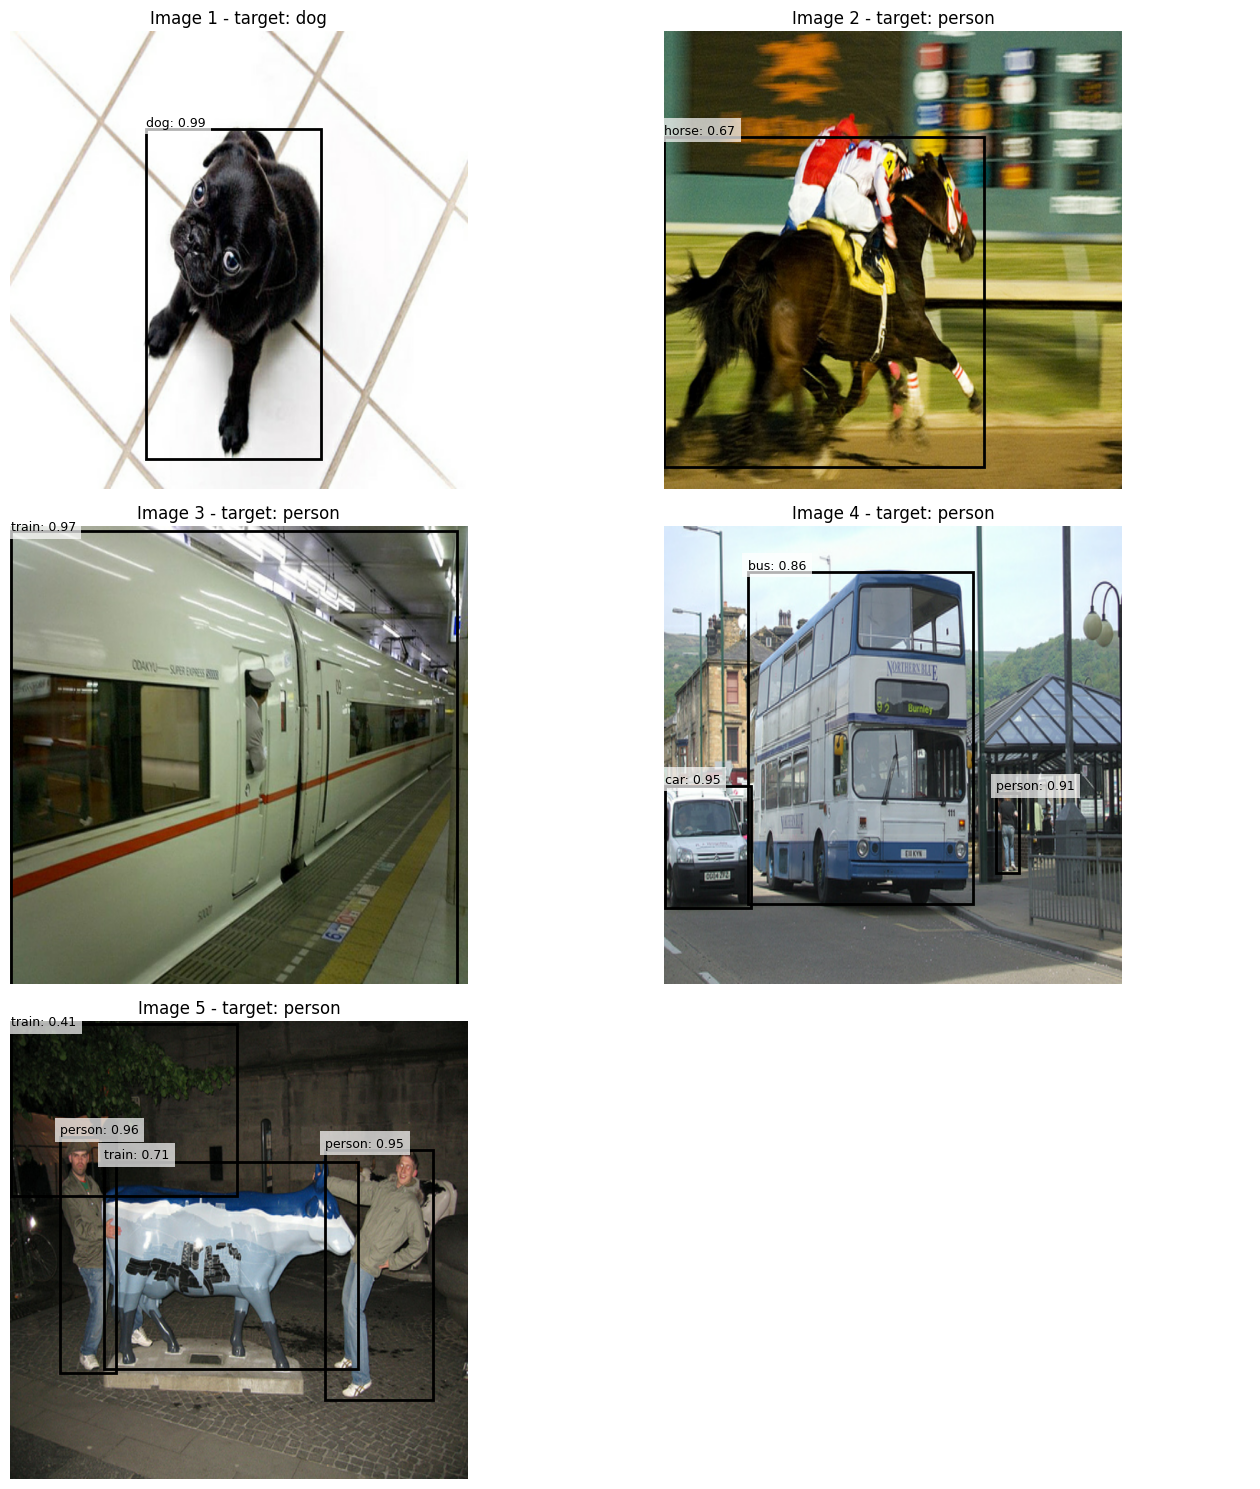

In [21]:
CONF_THRESHOLD = 0.25

num_images = len(images_np)
cols = 2
rows = int(np.ceil(num_images / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = np.array(axes).reshape(-1)

for i in range(num_images):
    ax = axes[i]
    img = images_np[i].astype("uint8").copy()
    ax.imshow(img)

    pred_boxes = np.array(predictions["boxes"][i])
    pred_classes = np.array(predictions["classes"][i]).astype(int)
    pred_conf = np.array(predictions["confidence"][i])

    valid_mask = pred_conf >= CONF_THRESHOLD
    pred_boxes = pred_boxes[valid_mask]
    pred_classes = pred_classes[valid_mask]
    pred_conf = pred_conf[valid_mask]

    for box, cls, conf in zip(pred_boxes, pred_classes, pred_conf):
        x, y, w, h = box

        rect = plt.Rectangle(
            (x, y), w, h,
            fill=False,
            linewidth=2
        )
        ax.add_patch(rect)

        label = label_names[cls] if 0 <= cls < len(label_names) else str(cls)
        ax.text(
            x,
            max(y - 5, 5),
            f"{label}: {conf:.2f}",
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

    ax.set_title(f"Image {i+1} - target: {selected_main_class[i]}")
    ax.axis("off")

for j in range(num_images, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [22]:
for _, row in results_df.iterrows():
    print(f"Image {row['Image']}:")
    print(f"  Main Target Class   : {row['Main Target Class']}")
    print(f"  Correct Detections  : {row['Correct Detections']}")
    print(f"  Confidence Scores   : {row['Confidence Scores']}")
    print(f"  Missed Objects      : {row['Missed Objects']}")
    print(f"  Incorrect Labels    : {row['Incorrect Labels']}")
    print("-" * 60)

Image 1:
  Main Target Class   : dog
  Correct Detections  : 1
  Confidence Scores   : [0.989]
  Missed Objects      : []
  Incorrect Labels    : []
------------------------------------------------------------
Image 2:
  Main Target Class   : person
  Correct Detections  : 1
  Confidence Scores   : [0.671]
  Missed Objects      : ['horse', 'person', 'person']
  Incorrect Labels    : []
------------------------------------------------------------
Image 3:
  Main Target Class   : person
  Correct Detections  : 1
  Confidence Scores   : [0.972]
  Missed Objects      : ['person']
  Incorrect Labels    : []
------------------------------------------------------------
Image 4:
  Main Target Class   : person
  Correct Detections  : 3
  Confidence Scores   : [0.951, 0.908, 0.863]
  Missed Objects      : ['person']
  Incorrect Labels    : []
------------------------------------------------------------
Image 5:
  Main Target Class   : person
  Correct Detections  : 2
  Confidence Scores   : [0.9